# Lib


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [2]:
pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

# Data


In [3]:
df = pd.read_csv("../data/clean/data.csv", parse_dates=["date"])
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

print("Shape:", df.shape)
df.head()

Shape: (306000, 30)


,location_id,location_name,date,pm10,pm2_5,carbon_monoxide,sulphur_dioxide,ozone,nitrogen_dioxide,aerosol_optical_depth,dust,us_aqi_pm2_5,us_aqi_pm10,us_aqi_nitrogen_dioxide,us_aqi_carbon_monoxide,us_aqi_ozone,us_aqi_sulphur_dioxide,us_aqi,temperature_2m,relative_humidity_2m,rain,surface_pressure,cloud_cover,wind_speed_10m,wind_direction_10m,weather_code,sunshine_duration,boundary_layer_height,dew_point_2m,is_day
0,1566083,Ho Chi Minh City,2023-01-01 00:00:00,95.0,65.0,993.0,37.50,25.0,84.40,0.29,0.0,133.11458,58.687496,41.568165,9.687199,24.002783,20.447111,133.11458,23.85,61.484700,0.0,1013.40027,100.0,11.304229,9.162280,3.0,0.0,70.0,16.0,0.0
1,1566083,Ho Chi Minh City,2023-01-01 01:00:00,86.1,59.0,846.0,30.75,28.0,70.25,0.25,0.0,132.65625,58.570840,34.599094,10.109903,18.784786,16.766632,132.65625,23.30,62.749770,0.0,1013.19920,100.0,10.739833,13.570457,3.0,0.0,80.0,15.8,0.0
2,1566083,Ho Chi Minh City,2023-01-01 02:00:00,83.4,57.0,821.0,28.90,26.0,65.80,0.24,0.0,131.73958,58.312500,32.407406,10.200483,14.784323,15.757906,131.73958,22.75,64.459640,0.0,1012.69824,100.0,8.287822,2.489499,3.0,0.0,105.0,15.7,0.0
3,1566083,Ho Chi Minh City,2023-01-01 03:00:00,80.1,54.8,834.0,28.45,22.0,63.95,0.24,0.0,130.64583,58.002083,31.496256,10.055555,12.117347,15.512541,130.64583,22.25,65.602090,0.0,1012.29730,100.0,8.669949,4.763556,3.0,0.0,135.0,15.5,0.0
4,1566083,Ho Chi Minh City,2023-01-01 04:00:00,69.4,47.5,838.0,27.20,20.0,60.10,0.23,0.0,129.43752,57.658333,29.600079,9.801933,11.421614,14.830973,129.43752,21.95,66.812325,0.0,1012.19680,100.0,7.928178,357.397500,3.0,0.0,145.0,15.5,0.0


# Data Quality Check


## Overview


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 306000 entries, 0 to 305999
Data columns (total 30 columns):
 #   Column                   Non-Null Count   Dtype         
---  ------                   --------------   -----         
 0   location_id              306000 non-null  int64         
 1   location_name            306000 non-null  str           
 2   date                     306000 non-null  datetime64[us]
 3   pm10                     306000 non-null  float64       
 4   pm2_5                    306000 non-null  float64       
 5   carbon_monoxide          306000 non-null  float64       
 6   sulphur_dioxide          306000 non-null  float64       
 7   ozone                    306000 non-null  float64       
 8   nitrogen_dioxide         306000 non-null  float64       
 9   aerosol_optical_depth    306000 non-null  float64       
 10  dust                     306000 non-null  float64       
 11  us_aqi_pm2_5             306000 non-null  float64       
 12  us_aqi_pm10              30

In [5]:
n_locations = df["location_id"].nunique()
date_range_days = (df["date"].max() - df["date"].min()).days + 1
expected_rows = n_locations * date_range_days * 24

print(f"Locations     : {n_locations}")
print(
    f"Date range     : {df['date'].min()}  ->  {df['date'].max()}  ({date_range_days} days)"
)
print(f"Expected rows : {expected_rows:,}")
print(f"Actual rows : {len(df):,}")
print(
    f"Missing rows : {expected_rows - len(df):,} rows ({(expected_rows - len(df)) / expected_rows * 100:.2f}%)"
)

Locations     : 10
Date range     : 2023-01-01 00:00:00  ->  2026-06-28 23:00:00  (1275 days)
Expected rows : 306,000
Actual rows : 306,000
Missing rows : 0 rows (0.00%)


In [6]:
df[["location_id", "location_name"]].drop_duplicates().reset_index(drop=True)

,location_id,location_name
0,1566083,Ho Chi Minh City
1,1587923,Bien Hoa
2,9075789,Long Khánh
3,1565022,Thu Dau Mot
4,12382296,Thuận An
5,1583518,Dĩ An
6,8594709,Thanh Pho Ba Ria
7,1562414,Vũng Tàu
8,1566559,Tay Ninh
9,1582436,Dong Xoai


## Dtype


In [7]:
print(df.dtypes)

location_id                         int64
location_name                         str
date                       datetime64[us]
pm10                              float64
pm2_5                             float64
carbon_monoxide                   float64
sulphur_dioxide                   float64
ozone                             float64
nitrogen_dioxide                  float64
aerosol_optical_depth             float64
dust                              float64
us_aqi_pm2_5                      float64
us_aqi_pm10                       float64
us_aqi_nitrogen_dioxide           float64
us_aqi_carbon_monoxide            float64
us_aqi_ozone                      float64
us_aqi_sulphur_dioxide            float64
us_aqi                            float64
temperature_2m                    float64
relative_humidity_2m              float64
rain                              float64
surface_pressure                  float64
cloud_cover                       float64
wind_speed_10m                    

## Missing value


In [8]:
missing_count = df.isnull().sum()
missing_pct = (missing_count / len(df) * 100).round(2)

missing_summary = pd.DataFrame(
    {"missing_count": missing_count, "missing_pct": missing_pct}
).sort_values("missing_pct", ascending=False)

missing_summary[missing_summary["missing_count"] > 0]

,missing_count,missing_pct
boundary_layer_height,43680,14.27


In [9]:
# missing by column
missing_percent = (df.isnull().sum() / len(df)) * 100
missing_percent.reset_index().rename(columns={0: "missing_percent"}).sort_values(
    "missing_percent", ascending=False
)

,index,missing_percent
27,boundary_layer_height,14.27451
0,location_id,0.00000
2,date,0.00000
3,pm10,0.00000
4,pm2_5,0.00000
1,location_name,0.00000
6,sulphur_dioxide,0.00000
7,ozone,0.00000
8,nitrogen_dioxide,0.00000
9,aerosol_optical_depth,0.00000


In [10]:
col_to_check = "boundary_layer_height"

if df[col_to_check].isnull().sum() > 0:
    missing_by_location = df[df[col_to_check].isnull()].groupby("location_name").size()
    print(f"Missing '{col_to_check}' by location:")
    print(missing_by_location)
    print()
    missing_dates = df[df[col_to_check].isnull()]["date"]
    print(
        f"Date range of missing values: [{missing_dates.min()} -> {missing_dates.max()}]"
    )

Missing 'boundary_layer_height' by location:
location_name
Bien Hoa            4368
Dong Xoai           4368
Dĩ An               4368
Ho Chi Minh City    4368
Long Khánh          4368
Tay Ninh            4368
Thanh Pho Ba Ria    4368
Thu Dau Mot         4368
Thuận An            4368
Vũng Tàu            4368
dtype: int64

Date range of missing values: [2024-01-01 07:00:00 -> 2024-07-01 06:00:00]


## Duplicated


In [11]:
full_dup = df.duplicated().sum()
key_dup = df.duplicated(subset=["location_id", "date"]).sum()

print(f"Rows with all columns duplicated        : {full_dup}")
print(f"Rows with duplicated (location_id,date) : {key_dup}")

Rows with all columns duplicated        : 0
Rows with duplicated (location_id,date) : 0


## Check gap, continous of hourly by location


In [12]:
for loc_id, loc_name in df[["location_id", "location_name"]].drop_duplicates().values:
    df_loc = df[df["location_id"] == loc_id].sort_values("date")
    expected_range = pd.date_range(
        start=df_loc["date"].min(), end=df_loc["date"].max(), freq="h"
    )
    missing_hours = expected_range.difference(df_loc["date"])
    if len(missing_hours) > 0:
        print(f"{loc_name:<20}: missing {len(missing_hours)} hour(s)")
    else:
        print(f"{loc_name:<20}: complete, no missing hours")

Ho Chi Minh City    : complete, no missing hours
Bien Hoa            : complete, no missing hours
Long Khánh          : complete, no missing hours
Thu Dau Mot         : complete, no missing hours
Thuận An            : complete, no missing hours
Dĩ An               : complete, no missing hours
Thanh Pho Ba Ria    : complete, no missing hours
Vũng Tàu            : complete, no missing hours
Tay Ninh            : complete, no missing hours
Dong Xoai           : complete, no missing hours


## Univariate


## Weather


### Numerical


In [13]:
weather_numeric_cols = [
    "temperature_2m",
    "relative_humidity_2m",
    "rain",
    "surface_pressure",
    "cloud_cover",
    "wind_speed_10m",
    "wind_direction_10m",
    "sunshine_duration",
    "boundary_layer_height",
    "dew_point_2m",
]

df[weather_numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
temperature_2m,306000.0,27.278651,3.099039,14.900000,25.000000,26.750000,29.350000,39.40000
relative_humidity_2m,306000.0,78.532980,15.857423,21.913445,68.632650,81.925280,91.755445,100.00000
rain,306000.0,0.253961,1.045512,0.000000,0.000000,0.000000,0.100000,35.70000
surface_pressure,306000.0,1005.396429,6.168712,980.791140,1004.066800,1007.213100,1009.288640,1018.40576
cloud_cover,306000.0,75.664696,34.652795,0.000000,54.000000,98.000000,100.000000,100.00000
wind_speed_10m,306000.0,8.879463,5.573281,0.000000,4.843305,7.674842,11.720751,44.42610
wind_direction_10m,306000.0,169.931917,92.642654,0.556242,99.619660,156.705410,241.858490,360.00000
sunshine_duration,306000.0,1483.144757,1731.918614,0.000000,0.000000,0.000000,3600.000000,3600.00000
boundary_layer_height,262320.0,512.182744,438.933942,10.000000,170.000000,390.000000,720.000000,2865.00000
dew_point_2m,306000.0,22.804125,2.383974,8.550000,21.550000,23.650000,24.500000,28.15000


**Range**:

- `relative_humidity_2m` must be in [0, 100]
- `cloud_cover` must be in [0, 100]
- `wind_direction_10m` must be in [0, 360]
- `rain`, `sunshine_duration`, `boundary_layer_height` not negative


In [14]:
range_checks = {
    "relative_humidity_2m": (0, 100),
    "cloud_cover": (0, 100),
    "wind_direction_10m": (0, 360),
}

for col, (lo, hi) in range_checks.items():
    invalid = df[(df[col] < lo) | (df[col] > hi)]
    print(f"{col:<25} out of [{lo},{hi}]      : {len(invalid)} rows")

non_negative_cols = ["rain", "sunshine_duration", "boundary_layer_height"]
for col in non_negative_cols:
    invalid = df[df[col] < 0]
    print(f"{col:<25} has negative values : {len(invalid)} rows")

relative_humidity_2m      out of [0,100]      : 0 rows
cloud_cover               out of [0,100]      : 0 rows
wind_direction_10m        out of [0,360]      : 0 rows
rain                      has negative values : 0 rows
sunshine_duration         has negative values : 0 rows
boundary_layer_height     has negative values : 0 rows


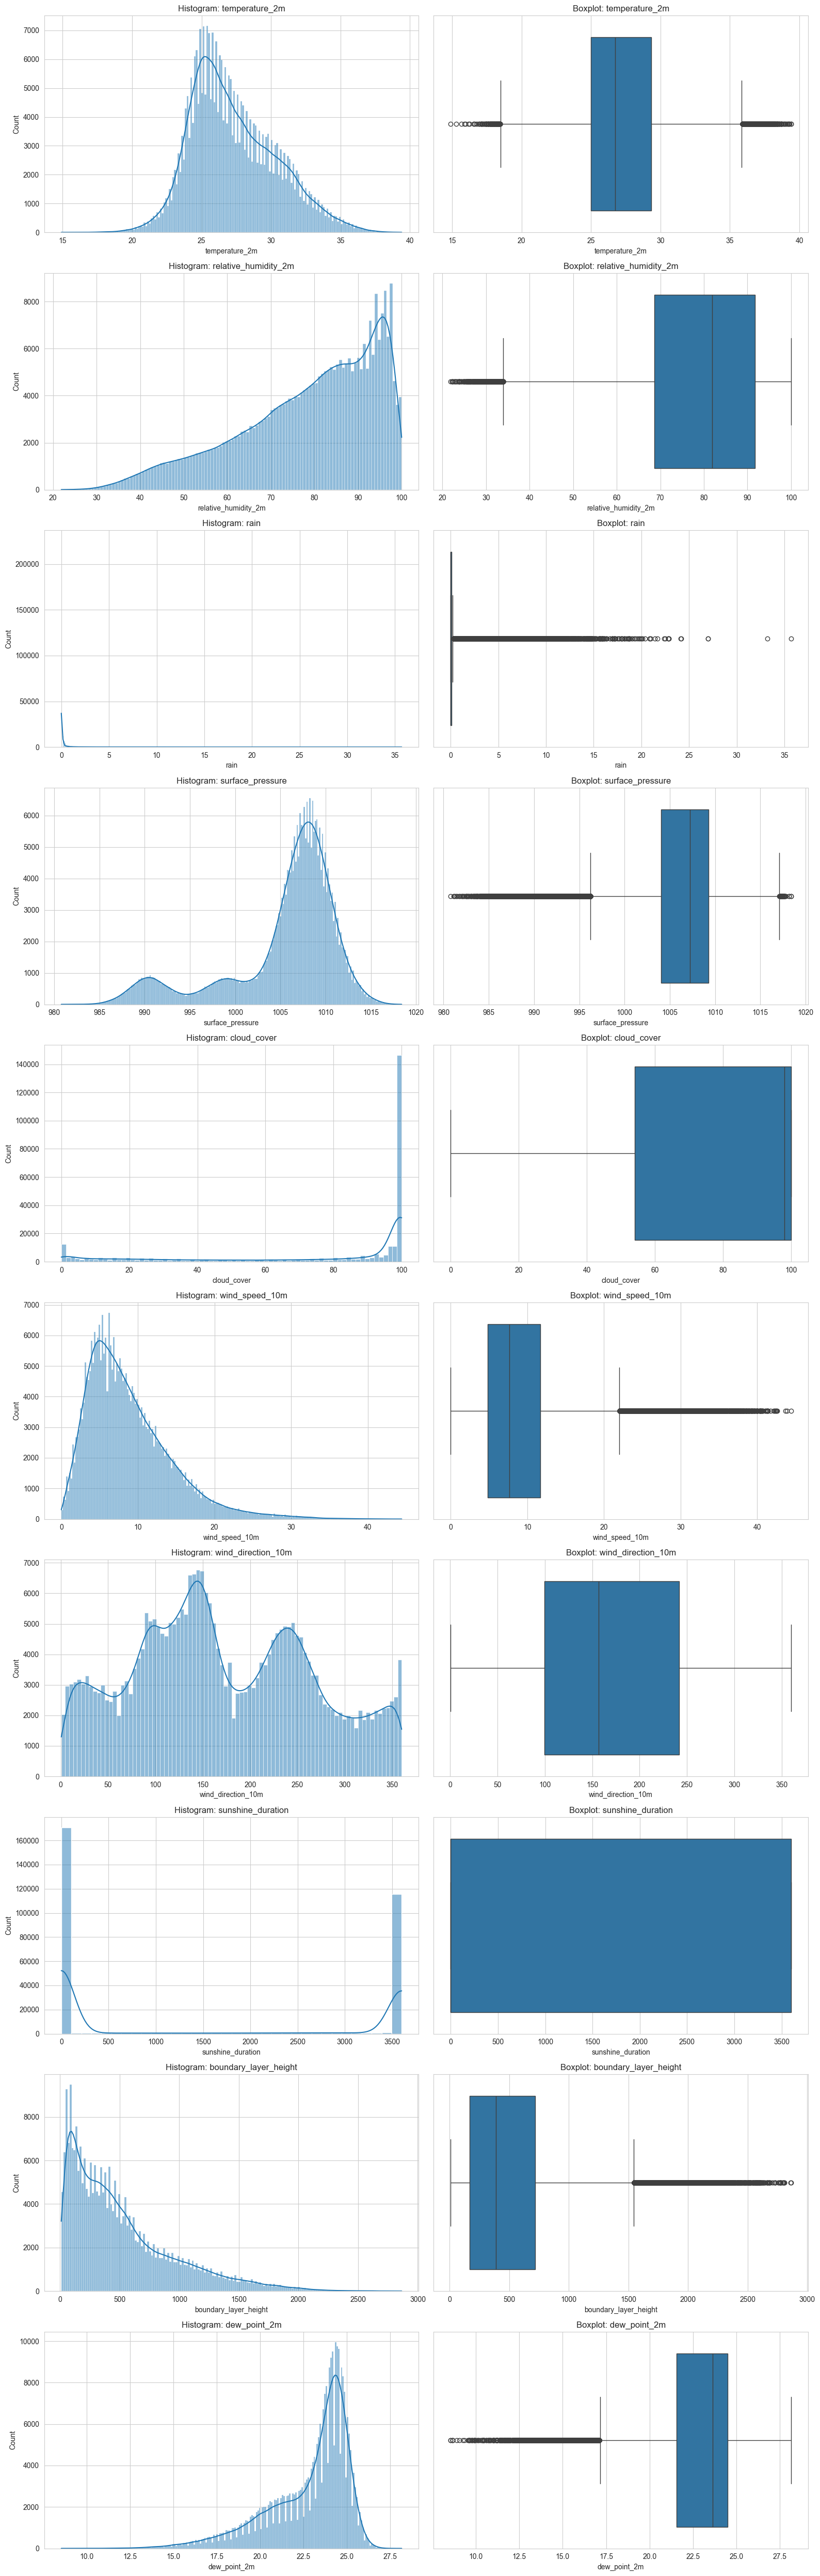

In [15]:
# Histogram + Boxplot
fig, axes = plt.subplots(
    len(weather_numeric_cols), 2, figsize=(16, 5 * len(weather_numeric_cols))
)

for i, col in enumerate(weather_numeric_cols):
    sns.histplot(df[col].dropna(), kde=True, ax=axes[i, 0])
    axes[i, 0].set_title(f"Histogram: {col}")

    sns.boxplot(x=df[col], ax=axes[i, 1])
    axes[i, 1].set_title(f"Boxplot: {col}")

plt.tight_layout()
plt.show()

### Categorical


In [16]:
weather_category_cols = [
    "weather_code",
    "is_day",
]

In [17]:
for col in weather_category_cols:
    print(f"{col} unique values: {df[col].nunique()}")
    print(df[col].unique())
    print()

weather_code unique values: 10
[ 3. 51.  1.  0.  2. 53. 63. 61. 55. 65.]

is_day unique values: 2
[0. 1.]



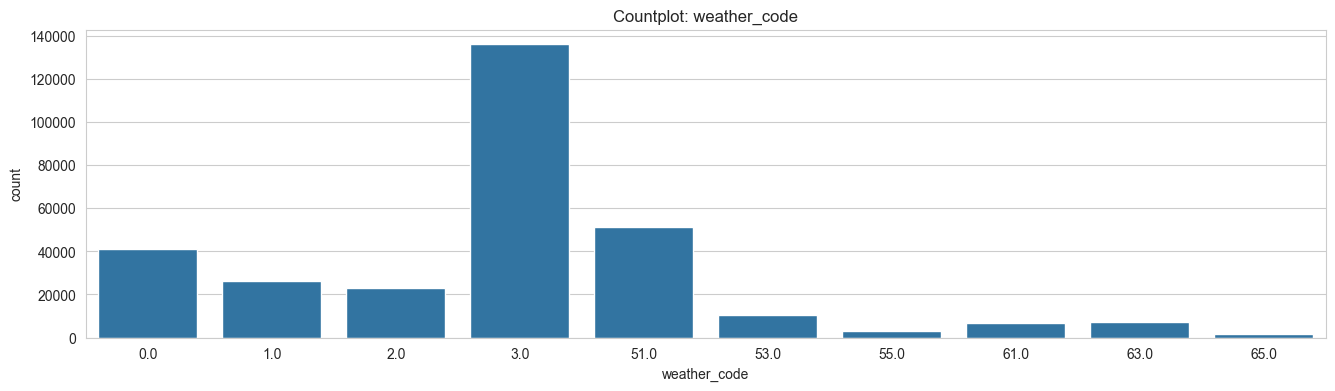

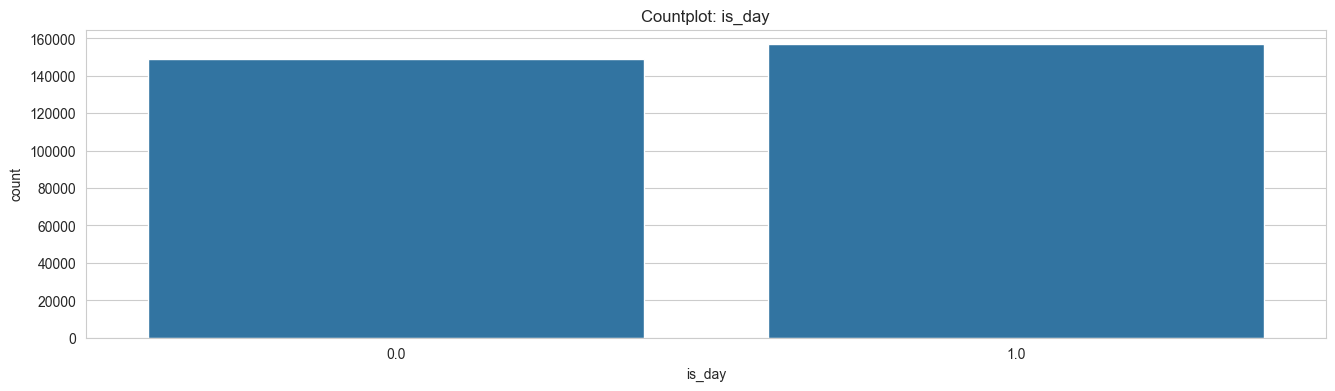

In [18]:
for col in weather_category_cols:
    plt.figure(figsize=(16, 4))
    sns.countplot(x=col, data=df)
    plt.title(f"Countplot: {col}")
    plt.show()

## Air Quality


In [19]:
aqi_cols = [
    "pm10",
    "pm2_5",
    "carbon_monoxide",
    "sulphur_dioxide",
    "ozone",
    "nitrogen_dioxide",
    "aerosol_optical_depth",
    "dust",
    "us_aqi_pm2_5",
    "us_aqi_pm10",
    "us_aqi_nitrogen_dioxide",
    "us_aqi_carbon_monoxide",
    "us_aqi_ozone",
    "us_aqi_sulphur_dioxide",
    "us_aqi",
]

In [20]:
df[aqi_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
pm10,306000.0,27.814196,15.403976,0.200000,17.100000,24.200000,34.900000,203.00000
pm2_5,306000.0,21.597569,13.407357,0.200000,12.400000,18.200000,27.200000,200.70000
carbon_monoxide,306000.0,392.513788,288.653499,33.000000,220.000000,308.000000,461.000000,5494.00000
sulphur_dioxide,306000.0,13.955134,12.920467,0.000000,4.100000,9.700000,20.000000,96.60000
ozone,306000.0,64.098490,39.690360,0.000000,34.000000,60.000000,89.000000,357.00000
nitrogen_dioxide,306000.0,20.189302,17.878840,0.000000,6.400000,14.300000,29.600000,162.50000
aerosol_optical_depth,306000.0,0.329359,0.182593,0.020000,0.210000,0.290000,0.410000,2.63000
dust,306000.0,0.588065,1.643495,0.000000,0.000000,0.000000,0.000000,36.00000
us_aqi_pm2_5,306000.0,69.701721,24.597874,8.229165,53.271275,65.531910,82.881210,170.10965
us_aqi_pm10,306000.0,25.197213,10.874942,1.818181,17.022728,23.268941,31.784094,70.10834


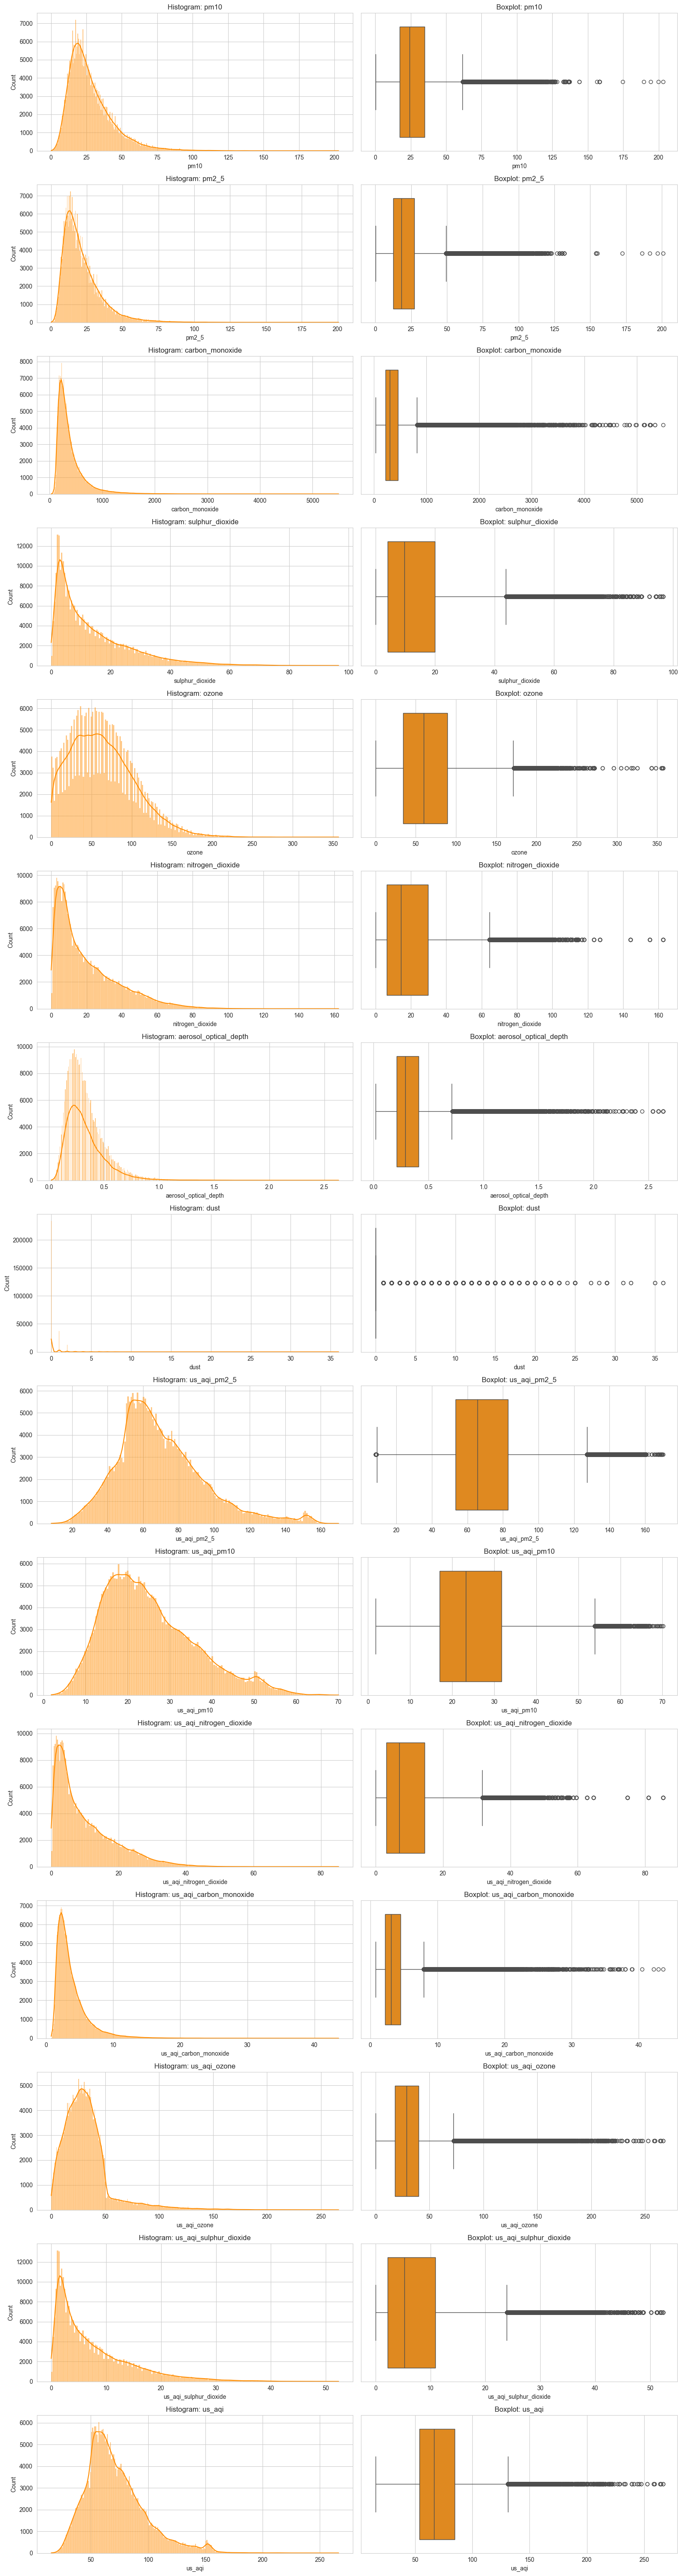

In [21]:
fig, axes = plt.subplots(len(aqi_cols), 2, figsize=(16, 4 * len(aqi_cols)))

for i, col in enumerate(aqi_cols):
    sns.histplot(df[col].dropna(), kde=True, ax=axes[i, 0], color="darkorange")
    axes[i, 0].set_title(f"Histogram: {col}")

    sns.boxplot(x=df[col], ax=axes[i, 1], color="darkorange")
    axes[i, 1].set_title(f"Boxplot: {col}")

plt.tight_layout()
plt.show()

In [22]:
# Check if us_aqi is the maximum value of the 6 components
components = [
    "us_aqi_pm2_5",
    "us_aqi_pm10",
    "us_aqi_nitrogen_dioxide",
    "us_aqi_carbon_monoxide",
    "us_aqi_ozone",
    "us_aqi_sulphur_dioxide",
]
calculated_max = df[components].max(axis=1)
mismatch = (df["us_aqi"] != calculated_max).sum()
print(f"Row mismatch that don't match the maximum: {mismatch} / {len(df)}")

Row mismatch that don't match the maximum: 0 / 306000


# Label


In [23]:
def aqi_to_category(value):
    if value <= 50:
        return "good"
    elif value <= 100:
        return "moderate"
    elif value <= 150:
        return "unhealthy for sensitive groups"
    elif value <= 200:
        return "unhealthy"
    elif value <= 300:
        return "very unhealthful"
    else:
        return "hazardous"


df["aqi_category"] = df["us_aqi"].apply(aqi_to_category)

category_order = [
    "good",
    "moderate",
    "unhealthy for sensitive groups",
    "unhealthy",
    "very unhealthful",
    "hazardous",
]

label_dist = (
    df["aqi_category"].value_counts(normalize=True).reindex(category_order).fillna(0)
    * 100
)
print(label_dist.round(2))

aqi_category
good                              17.81
moderate                          69.76
unhealthy for sensitive groups    10.98
unhealthy                          1.41
very unhealthful                   0.05
hazardous                          0.00
Name: proportion, dtype: float64


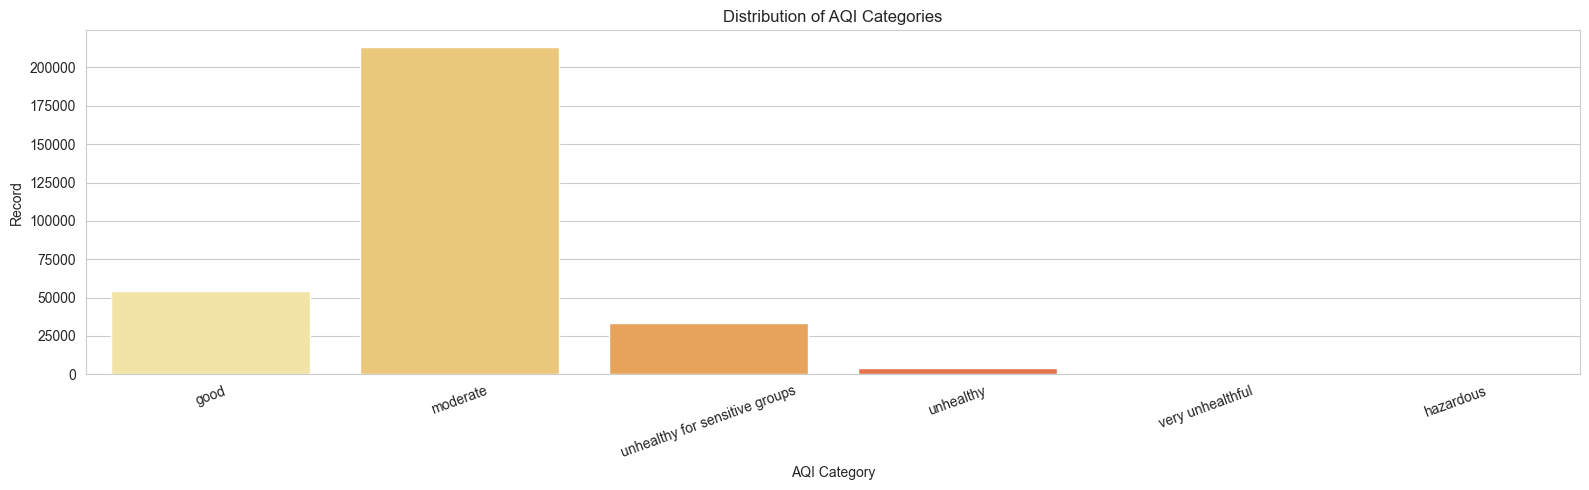

In [24]:
plt.figure(figsize=(16, 5))
sns.countplot(data=df, x="aqi_category", order=category_order, palette="YlOrRd")
plt.title("Distribution of AQI Categories")
plt.xlabel("AQI Category")
plt.ylabel("Record")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [25]:
counts = df["aqi_category"].value_counts()
imbalance_ratio = counts.max() / counts.min()
print(f"Class largest : {counts.idxmax()} ({counts.max():,} row)")
print(f"Class smallest : {counts.idxmin()} ({counts.min():,} row)")
print(f"Imbalance Ratio: {imbalance_ratio:.1f}")

Class largest : moderate (213,466 row)
Class smallest : very unhealthful (158 row)
Imbalance Ratio: 1351.1


# Save


In [26]:
df.to_csv("../data/clean/data1.csv", index=False)